In [135]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
import lightgbm as lgb
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import VotingClassifier

%matplotlib inline

In [136]:
# --- Loading the train dataset
train_dataset = pd.read_csv('data/train_dataset.csv')

# --- Loading the dataset
test_dataset = pd.read_csv('data/test_dataset.csv')
    

In [137]:
# --- Defining the function that will use the model to complete the test dataset

def complete_dataset(model_name, model):

    # Loading the test dataset
    test_dataset = pd.read_csv('data/test_dataset.csv')

    # Making the predictions
    test_pred = model.predict(test_dataset)
    test_dataset['Transition'] = test_pred

    # Dropping all columns but the Transition column
    test_dataset.drop(test_dataset.columns.difference(['Transition']), axis=1, inplace=True)

    # Creating a RowId column
    test_dataset['RowId'] = np.arange(1, test_dataset.shape[0] + 1)

    # Placing the RowId column in the first position
    cols = test_dataset.columns.tolist()
    cols = cols[-1:] + cols[:-1]
    test_dataset = test_dataset[cols]

    # Transforming the Transition column back to its original values
    replace_map = {'Transition': {0: 'CN-CN', 1: 'AD-AD', 2: 'CN-MCI', 3: 'MCI-AD', 4: 'MCI-MCI'}}
    test_dataset.replace(replace_map, inplace=True)
    test_dataset.head()

    # Saving the test dataset to a csv file
    test_dataset.to_csv('test_predictions_' + model_name + '.csv', index=False)

In [138]:
# --- Defining features and target
X = train_dataset.drop('Transition', axis=1)
y = train_dataset['Transition']

In [139]:
# Dropping the oversampled column if it exists in features
if 'oversampled' in X.columns:
    X = X.drop(columns=['oversampled'])

# dictionary to store the f1 scores of each model
results = {}

## Random Forest

In [140]:
# --- Implementing a Random Forest model

# Defining the hyperparameter distributions
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 6, 12, 20, None]
}

# Initializing base model
base_rf = RandomForestClassifier(random_state=123)

oversampling_indicator = train_dataset['oversampled'] # will be used to guarantee that oversampled data is only used in training

# Getting indices for non-oversampled and oversampled data
non_oversampled_indices = X[oversampling_indicator == 'NO'].index
oversampled_indices = X[oversampling_indicator == 'YES'].index

# Initializing StratifiedKFold for non-oversampled data
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

# Creating custom split indices that include oversampled data in training byt not in validation
custom_splits = []
for train_idx, val_idx in skf.split(
    X.loc[non_oversampled_indices], 
    y.loc[non_oversampled_indices]
):
    # Getting the actual indices from non_oversampled_indices
    actual_train_idx = non_oversampled_indices[train_idx]
    actual_val_idx = non_oversampled_indices[val_idx]
    
    # Add oversampled data to training set
    final_train_idx = np.concatenate([actual_train_idx, oversampled_indices])
    
    custom_splits.append((final_train_idx, actual_val_idx))

# Initializing RandomizedSearchCV with custom splits. This will search for the best hyperparameters
random_search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=custom_splits,
    scoring='f1_macro',
    random_state=123,
    n_jobs=-1,
    verbose=1
)

# Fitting the random search
random_search.fit(X, y)

# Getting the best model
best_rf = random_search.best_estimator_

# Initializing array for storing predictions
predictions = np.zeros(len(non_oversampled_indices))
probabilities = np.zeros((len(non_oversampled_indices), 5))

# Performing final cross-validation with best model
for fold, (train_idx, val_idx) in enumerate(custom_splits):
    # Training best model on combined data (original + oversampled)
    best_rf.fit(X.loc[train_idx], y.loc[train_idx])
    
    # Predicting on validation set (non-oversampled only)
    val_pred = best_rf.predict(X.loc[val_idx])
    val_prob = best_rf.predict_proba(X.loc[val_idx])
    
    # Storing predictions
    fold_indices = np.where(non_oversampled_indices.isin(val_idx))[0]
    predictions[fold_indices] = val_pred
    probabilities[fold_indices] = val_prob

# Calculating final score
f1_macro = f1_score(y.loc[non_oversampled_indices], predictions, average='macro')
results['rfc']= f1_macro

print('Random Forest Classifier Results:')
print('Best Parameters:', random_search.best_params_)
print('Best Cross-Validation Score:', random_search.best_score_)
print('Final Macro F1 Score:', f1_macro)

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Random Forest Classifier Results:
Best Parameters: {'n_estimators': 200, 'max_depth': 20}
Best Cross-Validation Score: 0.3986017231418766
Final Macro F1 Score: 0.4199891070655274


In [141]:
# --- Analyzing the confusion matrix

y_non_oversampled = y.loc[non_oversampled_indices]
rfc_pred = predictions

# Printing the confusion matrix
print("Confusion matrix")
print(confusion_matrix(y_non_oversampled, rfc_pred))

Confusion matrix
[[68  2  7  7 12]
 [ 2 29  0 21  8]
 [ 3  0  5  1  1]
 [15 16  0 25 12]
 [30  8  2 20 11]]


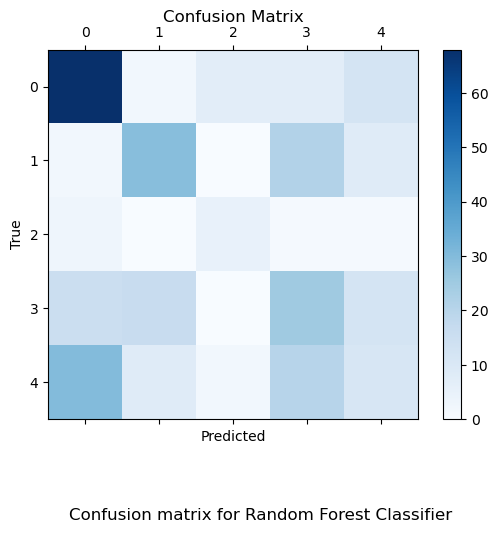

In [142]:

# --- Plotting the confusion matrix
fig, ax = plt.subplots()
cax = ax.matshow(confusion_matrix(y_non_oversampled, rfc_pred), cmap=plt.cm.Blues)
fig.colorbar(cax)

# Adding labels
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix', pad=20)

# Adding caption
caption = "Confusion matrix for Random Forest Classifier"
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

In [143]:
# --- Completing the test dataset
complete_dataset('RandomForestClassifier', best_rf)

## XGBoost

In [144]:
# --- Implementing an XGBoost model

oversampling_indicator = train_dataset['oversampled']

# Initializing XGBoost with best parameters
xgbc = xgb.XGBClassifier(
    objective='multi:softprob',
    random_state=123,
    num_class=5,
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05
)

# Getting indices of non-oversampled data
non_oversampled_indices = X[oversampling_indicator == 'NO'].index

# Initializing StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

# Initializing array for storing predictions
predictions = np.zeros(len(non_oversampled_indices))
probabilities = np.zeros((len(non_oversampled_indices), 5))

# Performing cross-validation
for fold, (train_idx, val_idx) in enumerate(skf.split(
    X.loc[non_oversampled_indices],
    y.loc[non_oversampled_indices]
)):
    # Getting the actual indices
    actual_train_idx = non_oversampled_indices[train_idx]
    actual_val_idx = non_oversampled_indices[val_idx]
    
    # Add oversampled data to training set
    oversampled_indices = X[oversampling_indicator == 'YES'].index
    final_train_idx = np.concatenate([actual_train_idx, oversampled_indices])
    
    # Training model on combined data (original + oversampled)
    xgbc.fit(
        X.loc[final_train_idx], 
        y.loc[final_train_idx],
        # Optional: add sample weights if needed
        # sample_weight=compute_sample_weights(y.loc[final_train_idx])
    )
    
    # Predicting on validation set (non-oversampled only)
    val_pred = xgbc.predict(X.loc[actual_val_idx])
    val_prob = xgbc.predict_proba(X.loc[actual_val_idx])
    
    # Storing predictions
    predictions[val_idx] = val_pred
    probabilities[val_idx] = val_prob
    
# Calculating final score
f1_macro = f1_score(y.loc[non_oversampled_indices], predictions, average='macro')
results['xgboost']= f1_macro

print('\nFinal XGBoost Classifier')
print(f'Overall Macro F1 Score: {f1_macro:.3f}')


Final XGBoost Classifier
Overall Macro F1 Score: 0.374


In [145]:
# --- Analyzing the confusion matrix

xgbc_pred = predictions

# Printing the confusion matrix
print("Confusion matrix")
print(confusion_matrix(y_non_oversampled, xgbc_pred))

Confusion matrix
[[66  3  5 10 12]
 [ 1 24  0 23 12]
 [ 2  1  4  2  1]
 [14 22  0 18 14]
 [30 10  1 19 11]]


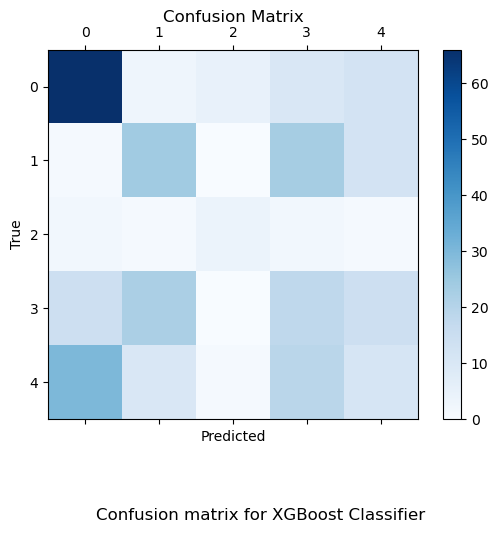

In [146]:
# --- Plotting the confusion matrix with a caption
fig, ax = plt.subplots()
cax = ax.matshow(confusion_matrix(y_non_oversampled, xgbc_pred), cmap=plt.cm.Blues)
fig.colorbar(cax)

# Adding labels
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix', pad=20)

# Adding caption
caption = "Confusion matrix for XGBoost Classifier"
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

In [147]:
# Completing the test dataset
complete_dataset('xgboost', xgbc)

## SVM

In [148]:
# --- SVM MODEL ---

# Defining the hyperparameter distributions
param_distributions = {
    'svc__C': np.logspace(-3, 3, 7),
    'svc__gamma': ['scale', 'auto'] + list(np.logspace(-3, 3, 7))
}

# Initializing the SVM model with pipeline
svm = make_pipeline(
    StandardScaler(),
    SVC(
        random_state=123,
        kernel='rbf',
        class_weight='balanced',
        probability=True,
        cache_size=1000
    )
)

oversampling_indicator = train_dataset['oversampled']

# Getting indices of non-oversampled and oversampled data
non_oversampled_indices = X[oversampling_indicator == 'NO'].index
oversampled_indices = X[oversampling_indicator == 'YES'].index

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

custom_splits = []
for train_idx, val_idx in skf.split(
    X.loc[non_oversampled_indices],
    y.loc[non_oversampled_indices]
):
    # Getting the actual indices
    actual_train_idx = non_oversampled_indices[train_idx]
    actual_val_idx = non_oversampled_indices[val_idx]
    
    # Add oversampled data to training set
    final_train_idx = np.concatenate([actual_train_idx, oversampled_indices])
    
    custom_splits.append((final_train_idx, actual_val_idx))

svm = RandomizedSearchCV(
    svm,
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=123
)

svm.fit(X, y)

best_svm = svm.best_estimator_

# Initializing arrays for storing predictions and probabilities
predictions = np.zeros(len(non_oversampled_indices))
probabilities = np.zeros((len(non_oversampled_indices), len(np.unique(y))))

# Performing cross-validation
for fold, (train_idx, val_idx) in enumerate(custom_splits):
    best_svm.fit(X.iloc[train_idx], y.loc[train_idx])
    
    # Predicting on validation set
    val_pred = best_svm.predict(X.loc[val_idx])
    val_prob = best_svm.predict_proba(X.loc[val_idx])
    
    # Storing predictions and probabilities
    fold_indices = np.where(non_oversampled_indices.isin(val_idx))[0]
    predictions[fold_indices] = val_pred
    probabilities[fold_indices] = val_prob

# Calculating final scores
final_f1_macro = f1_score(y.loc[non_oversampled_indices], predictions, average='macro')
results['svm']= final_f1_macro

print('\nFinal SVM Results')
print(f'Overall Macro F1 Score: {final_f1_macro:.3f}')


Final SVM Results
Overall Macro F1 Score: 0.356


In [149]:
# Complete the dataset
complete_dataset('svm', svm)

## Logistic Regression

In [150]:
# --- LOGISTIC REGRESSION ---

# Optional: Add hyperparameter tuning
param_distributions = {
    'logisticregression__C': np.logspace(-4, 4, 9),
    'logisticregression__penalty': ['l1', 'l2', 'elasticnet'],
    'logisticregression__l1_ratio': [0.2, 0.5, 0.9]
}

# Initializing the logistic regression model with pipeline
log_reg = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        random_state=123,
        max_iter=2000,
        class_weight='balanced',
        multi_class='multinomial',
        solver='saga'
    )
)

oversampling_indicator = train_dataset['oversampled']

non_oversampled_indices = X[oversampling_indicator == 'NO'].index
oversampled_indices = X[oversampling_indicator == 'YES'].index

# Initializing StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

custom_splits = []
for train_idx, val_idx in skf.split(
    X.loc[non_oversampled_indices],
    y.loc[non_oversampled_indices]
):
    # Getting the actual indices
    actual_train_idx = non_oversampled_indices[train_idx]
    actual_val_idx = non_oversampled_indices[val_idx]
    
    # Add oversampled data to training set
    final_train_idx = np.concatenate([actual_train_idx, oversampled_indices])
    
    custom_splits.append((final_train_idx, actual_val_idx))


log_reg = RandomizedSearchCV(
    log_reg,
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=123
)

log_reg.fit(X, y)
best_log_reg = log_reg.best_estimator_


# Initializing arrays for storing predictions and probabilities
predictions = np.zeros(len(non_oversampled_indices))
probabilities = np.zeros((len(non_oversampled_indices), len(np.unique(y))))

# Performing cross-validation
for fold, (train_idx, val_idx) in enumerate(custom_splits):

    # Training model
    best_log_reg.fit(X.iloc[train_idx], y.iloc[train_idx])

    # Predicting on validation set
    val_pred = best_log_reg.predict(X.loc[val_idx])
    val_prob = best_log_reg.predict_proba(X.loc[val_idx])
    
    # Storing predictions and probabilities
    fold_indices = np.where(non_oversampled_indices.isin(val_idx))[0]
    predictions[fold_indices] = val_pred
    probabilities[fold_indices] = val_prob

# Calculating final scores
final_f1_macro = f1_score(y.loc[non_oversampled_indices], predictions, average='macro')
results['lr']= final_f1_macro

print('\nFinal Logistic Regression Results')
print(f'Overall Macro F1 Score: {final_f1_macro:.3f}')

/home/ricp6/miniconda3/envs/project/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/ricp6/miniconda3/envs/project/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/ricp6/miniconda3/envs/project/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/ricp6/miniconda3/envs/project/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 


Final Logistic Regression Results
Overall Macro F1 Score: 0.317


/home/ricp6/miniconda3/envs/project/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [151]:
# Complete the dataset
complete_dataset('logreg', log_reg)

In [152]:
# Optional: Add hyperparameter tuning
param_distributions = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'feature_fraction': [0.6, 0.7, 0.9],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0, 0.1, 0.5, 1.0],
    'min_child_samples': [10, 20, 30, 50]
}

# Initializing LightGBM with better parameters for your case
lgbm = lgb.LGBMClassifier(
    objective='multiclass',
    random_state=123,
    num_class=5,
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    class_weight='balanced',  # Handle class imbalance
    boosting_type='goss',    # Gradient-based One-Side Sampling, good for imbalanced data
    verbose=-1,              
    n_jobs=-1,              
    feature_fraction=0.8,    
    reg_alpha=0.1,          
    reg_lambda=0.1,         
    min_child_samples=20    
)


oversampling_indicator = train_dataset['oversampled']

non_oversampled_indices = X[oversampling_indicator == 'NO'].index
oversampled_indices = X[oversampling_indicator == 'YES'].index

# Initializing StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

custom_splits = []
for train_idx, val_idx in skf.split(
    X.loc[non_oversampled_indices],
    y.loc[non_oversampled_indices]
):
    # Getting the actual indices
    actual_train_idx = non_oversampled_indices[train_idx]
    actual_val_idx = non_oversampled_indices[val_idx]
    
    # Add oversampled data to training set
    final_train_idx = np.concatenate([actual_train_idx, oversampled_indices])
    
    custom_splits.append((final_train_idx, actual_val_idx))


lgbm = RandomizedSearchCV(
    lgbm,
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=123
)

lgbm.fit(X, y)
best_lgbm = lgbm.best_estimator_


# Initializing arrays for storing predictions and probabilities
predictions = np.zeros(len(non_oversampled_indices))
probabilities = np.zeros((len(non_oversampled_indices), 5))  # 5 classes

# Performing cross-validation
for fold, (train_idx, val_idx) in enumerate(custom_splits):
    
    best_lgbm.fit(X.iloc[train_idx], y.iloc[train_idx])
    
    # Predicting on validation set
    val_pred = best_lgbm.predict(X.loc[val_idx])
    val_prob = best_lgbm.predict_proba(X.loc[val_idx])

    # Storing predictions and probabilities
    fold_indices = np.where(non_oversampled_indices.isin(val_idx))[0]
    predictions[fold_indices] = val_pred
    probabilities[fold_indices] = val_prob
    
# Calculating final scores
final_f1_macro = f1_score(y.loc[non_oversampled_indices], predictions, average='macro')
results['lgbm']= final_f1_macro

print('\nFinal LightGBM Results')
print(f'Overall Macro F1 Score: {final_f1_macro:.3f}')

print('\nConfusion Matrix:')
print(confusion_matrix(y.loc[non_oversampled_indices], predictions))


Final LightGBM Results
Overall Macro F1 Score: 0.352

Confusion Matrix:
[[62  4  6  7 17]
 [ 1 25  1 21 12]
 [ 2  1  5  1  1]
 [ 9 25  1 14 19]
 [28 11  3 20  9]]


In [153]:
# Complete the dataset
complete_dataset('lightgbm', lgbm)

# Stacking Classifier

In [155]:
# Cria o Stacking Classifier
stacking_model = StackingClassifier(
    estimators=[
        ('rfc', best_rf),
        ('xgboost', xgbc),
        ('svm', best_svm),
        ('lr', best_log_reg),
        ('lgbm', best_lgbm)
    ],
    final_estimator=LogisticRegression(),  # Meta-modelo para combinar previsões
    cv=5
)

oversampling_indicator = train_dataset['oversampled']

# Getting indices of non-oversampled data
non_oversampled_indices = X[oversampling_indicator == 'NO'].index

# Initializing StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

# Initializing array for storing predictions
predictions = np.zeros(len(non_oversampled_indices))
probabilities = np.zeros((len(non_oversampled_indices), 5))

# Performing cross-validation
for fold, (train_idx, val_idx) in enumerate(skf.split(
    X.loc[non_oversampled_indices],
    y.loc[non_oversampled_indices]
)):
    # Getting the actual indices
    actual_train_idx = non_oversampled_indices[train_idx]
    actual_val_idx = non_oversampled_indices[val_idx]
    
    # Add oversampled data to training set
    oversampled_indices = X[oversampling_indicator == 'YES'].index
    final_train_idx = np.concatenate([actual_train_idx, oversampled_indices])
    
    # Training model on combined data (original + oversampled)
    stacking_model.fit(
        X.loc[final_train_idx], 
        y.loc[final_train_idx],
        # Optional: add sample weights if needed
        # sample_weight=compute_sample_weights(y.loc[final_train_idx])
    )
    
    # Predicting on validation set (non-oversampled only)
    val_pred = stacking_model.predict(X.loc[actual_val_idx])
    val_prob = stacking_model.predict_proba(X.loc[actual_val_idx])
    
    # Storing predictions
    predictions[val_idx] = val_pred
    probabilities[val_idx] = val_prob

# Calculating final scores
final_f1_macro = f1_score(y.loc[non_oversampled_indices], predictions, average='macro')
results['st']= final_f1_macro

print('\nFinal Stacking Results')
print(f'Overall Macro F1 Score: {final_f1_macro:.3f}')

/home/ricp6/miniconda3/envs/project/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/ricp6/miniconda3/envs/project/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/ricp6/miniconda3/envs/project/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/ricp6/miniconda3/envs/project/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not conver


Final Stacking Results
Overall Macro F1 Score: 0.400


In [156]:
# Complete the dataset
complete_dataset('stacking', stacking_model)

# Voting Classifier

In [157]:
# Cria o Voting Classifier
voting_model = VotingClassifier(
    estimators=[
        ('rfc', best_rf),
        ('xgboost', xgbc),
        ('svm', best_svm),
        ('lr', best_log_reg),
        ('lgbm', best_lgbm)
    ],
    voting='soft'  # ou 'hard' para votação majoritária
)

oversampling_indicator = train_dataset['oversampled']

# Getting indices of non-oversampled data
non_oversampled_indices = X[oversampling_indicator == 'NO'].index

# Initializing StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

# Initializing array for storing predictions
predictions = np.zeros(len(non_oversampled_indices))
probabilities = np.zeros((len(non_oversampled_indices), 5))

# Performing cross-validation
for fold, (train_idx, val_idx) in enumerate(skf.split(
    X.loc[non_oversampled_indices],
    y.loc[non_oversampled_indices]
)):
    # Getting the actual indices
    actual_train_idx = non_oversampled_indices[train_idx]
    actual_val_idx = non_oversampled_indices[val_idx]
    
    # Add oversampled data to training set
    oversampled_indices = X[oversampling_indicator == 'YES'].index
    final_train_idx = np.concatenate([actual_train_idx, oversampled_indices])
    
    # Training model on combined data (original + oversampled)
    voting_model.fit(
        X.loc[final_train_idx], 
        y.loc[final_train_idx],
        # Optional: add sample weights if needed
        # sample_weight=compute_sample_weights(y.loc[final_train_idx])
    )
    
    # Predicting on validation set (non-oversampled only)
    val_pred = voting_model.predict(X.loc[actual_val_idx])
    val_prob = voting_model.predict_proba(X.loc[actual_val_idx])
    
    # Storing predictions
    predictions[val_idx] = val_pred
    probabilities[val_idx] = val_prob
    
# Calculating final scores
final_f1_macro = f1_score(y.loc[non_oversampled_indices], predictions, average='macro')
results['vote']= final_f1_macro

print('\nFinal Voting Results')
print(f'Overall Macro F1 Score: {final_f1_macro:.3f}')

/home/ricp6/miniconda3/envs/project/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/ricp6/miniconda3/envs/project/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/ricp6/miniconda3/envs/project/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/ricp6/miniconda3/envs/project/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not conver


Final Voting Results
Overall Macro F1 Score: 0.367


In [158]:
# Complete the dataset
complete_dataset('voting', voting_model)

# Resultados de cada Modelo

In [159]:
for model in results:
    print(f"Modelo: {model} - Score: {results[model]}")

Modelo: rfc - Score: 0.4199891070655274
Modelo: xgboost - Score: 0.374107997265892
Modelo: svm - Score: 0.3561417091599985
Modelo: lr - Score: 0.31722414767494433
Modelo: lgbm - Score: 0.352195749887921
Modelo: st - Score: 0.3995104822538307
Modelo: vote - Score: 0.3667362045697577


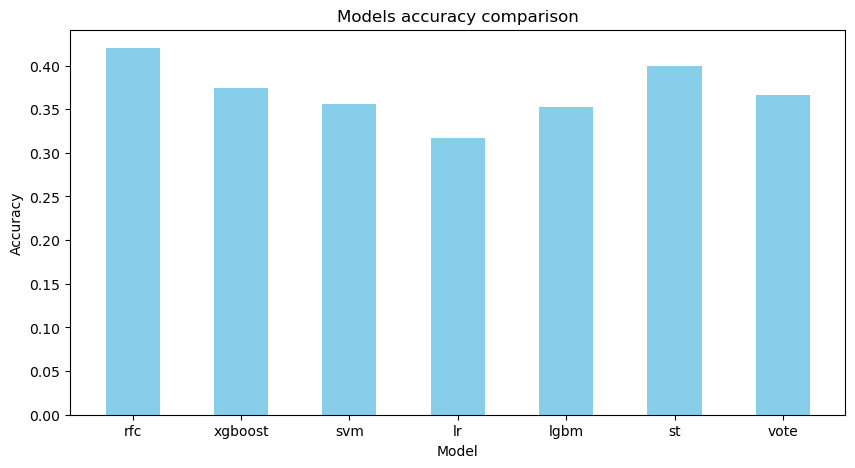

In [160]:
fig = plt.figure(figsize = (10, 5))

mod = results.keys()
acc = results.values()

plt.bar(mod, acc, color='skyblue', width = 0.5)
 
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Models accuracy comparison")

plt.show()